In [59]:
%pip install pymysql
%pip install mysql-connector-python pandas
%pip install SQLAlchemy
%pip install load_dotenv
%pip install pandas
%pip install matplotlib
%pip install ipython-sql
%pip install scipy
%pip install ace_tools
%pip install seaborn
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# Set up database

In [60]:
from dotenv import load_dotenv
import os
from IPython.display import display

load_dotenv()

user = os.getenv("DB_USER")
password = os.getenv("DB_PASS")
host = os.getenv("DB_HOST")
dbname = os.getenv("DB_NAME")

from sqlalchemy import create_engine
engine = create_engine(f"mysql+mysqlconnector://{user}:{password}@{host}/{dbname}", connect_args={'init_command': 'SET time_zone="+07:00"'})

# Sleep

In [61]:
import pandas as pd
import matplotlib.pyplot as plt

,SLEEP_START_CATEGORY,SLEEP_END_CATEGORY,WAKE_FEELING_CATEGORY,MINUTES_PER_DAY_CATEGORY,count
0,Early,Early,Good,None,1
1,Late,Early,Bad,None,1
2,Late,Early,Good,Acceptable,1
3,Late,Early,Good,Good,1
4,Late,Late,Good,Acceptable,2
5,Late,Late,Good,Good,3
6,Late,Late,Good,None,2


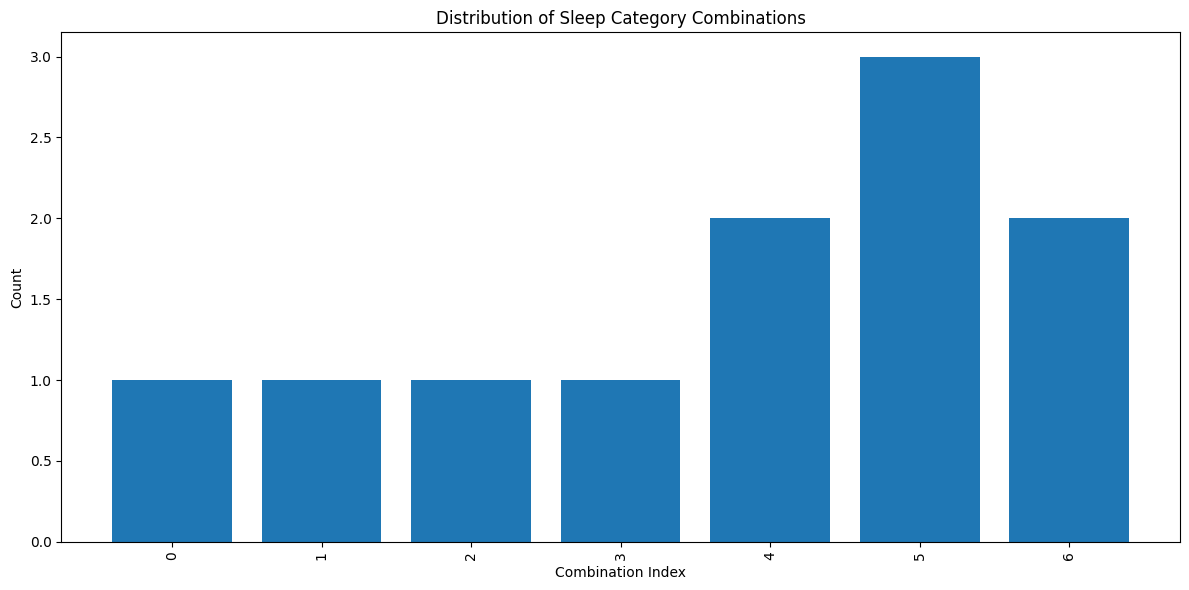

In [62]:
query = "SELECT * FROM ML_FOR_SLEEP"
df = pd.read_sql(query, engine)

combo_counts = df.groupby(
    [
        "SLEEP_START_CATEGORY",
        "SLEEP_END_CATEGORY",
        "WAKE_FEELING_CATEGORY",
        "MINUTES_PER_DAY_CATEGORY"
    ]
).size().reset_index(name="count")

display(combo_counts)

combo_counts["label"] = combo_counts.index.astype(str)

plt.figure(figsize=(12, 6))
plt.bar(combo_counts["label"], combo_counts["count"])
plt.xlabel("Combination Index")
plt.ylabel("Count")
plt.title("Distribution of Sleep Category Combinations")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [63]:
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Define features and target
features = ["SLEEP_START_CATEGORY", "SLEEP_END_CATEGORY", "WAKE_FEELING_CATEGORY"]
target = "MINUTES_PER_DAY_CATEGORY"

# Encode categorical features
X = combo_counts[features].apply(LabelEncoder().fit_transform)
y = LabelEncoder().fit_transform(combo_counts[target])

In [64]:
clf = DecisionTreeClassifier(max_depth=10, random_state=100)
clf.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,100
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


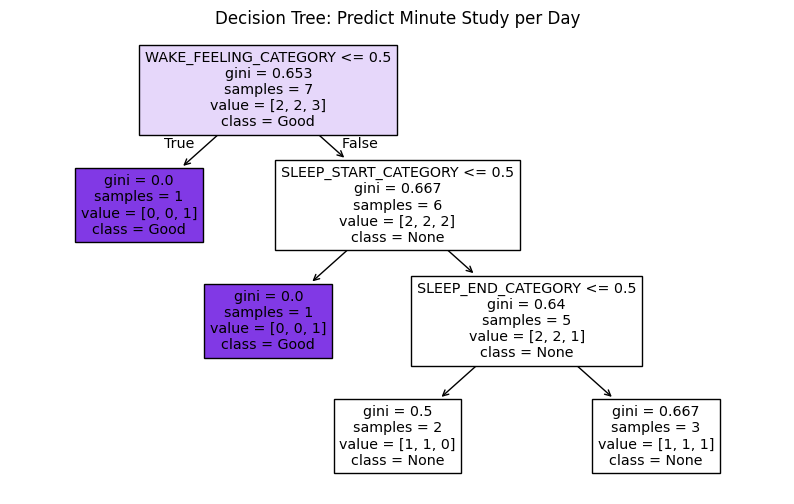

In [65]:
plt.figure(figsize=(10, 6))
plot_tree(clf, feature_names=features, class_names=['None', 'Acceptable', 'Good'], filled=True)
plt.title("Decision Tree: Predict Minute Study per Day")
plt.show()